Imports done ✅
Shape after cleaning: (7032, 20)
Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train: 5625 | Test: 1407
Preprocessor built ✅
All 3 pipelines built ✅

📊 Logistic Regression
   Accuracy: 0.8038
   F1 Score: 0.6080
   ROC-AUC:  0.7299

📊 Random Forest
   Accuracy: 0.7875
   F1 Score: 0.5477
   ROC-AUC:  0.6907

📊 XGBoost
   Accuracy: 0.7690
   F1 Score: 0.5480
   ROC-AUC:  0.6917

📊 Summary Table:
              Model  Accuracy  F1 Score  ROC-AUC
Logistic Regression  0.803838  0.607955 0.729949
      Random Forest  0.787491  0.547655 0.690672
            XGBoost  0.769012  0.547983 0.691733


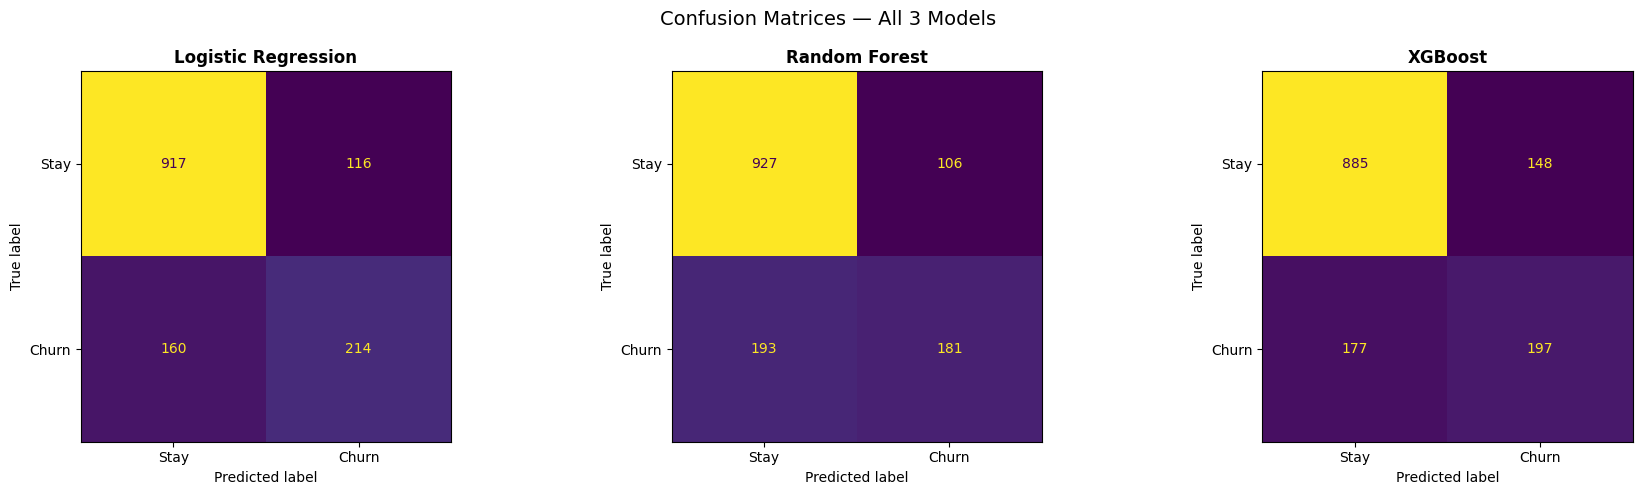

Best model: Logistic Regression
Pipeline saved ✅
Load verified ✅ | Accuracy: 0.8038379530916845

📊 Logistic Regression:
              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


📊 Random Forest:
              precision    recall  f1-score   support

        Stay       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407


📊 XGBoost:
              precision    recall  f1-score   support

        Stay       0.83      0.86      0.84      1033
       Churn       0.57      0.53      0.55       374

    accuracy                    

In [ ]:
# ============================================================
# DAY 8 — End-to-End ML Pipelines
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import joblib
print("Imports done ✅")

# ── Block 2: Load & Clean Data ────────────────────────────
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print("Shape after cleaning:", df.shape)
print("Churn distribution:\n", df['Churn'].value_counts())

# ── Block 3: Identify Columns & Split ─────────────────────
X = df.drop('Churn', axis=1)
y = df['Churn']
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

# ── Block 4: Build ColumnTransformer ─────────────────────
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)])
print("Preprocessor built ✅")

# ── Block 5: Build 3 Full Pipelines ──────────────────────
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42,
                                  eval_metric='logloss', verbosity=0))])
print("All 3 pipelines built ✅")

# ── Block 6: Train & Evaluate All Models ─────────────────
models = {'Logistic Regression': pipe_lr,
          'Random Forest': pipe_rf, 'XGBoost': pipe_xgb}
results = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results.append({'Model': name,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'F1 Score': f1_score(y_test, y_pred),
                    'ROC-AUC': roc_auc_score(y_test, y_pred)})
    print(f"\n📊 {name}")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"   ROC-AUC:  {roc_auc_score(y_test, y_pred):.4f}")
results_df = pd.DataFrame(results)
print("\n📊 Summary Table:")
print(results_df.to_string(index=False))

# ── Block 7: Confusion Matrices ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipeline) in zip(axes, models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Stay', 'Churn'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrices — All 3 Models', fontsize=14)
plt.tight_layout()
plt.show()

# ── Block 8: Save Best Pipeline ───────────────────────────
best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
best_pipeline = models[best_model_name]
joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')
print(f"Best model: {best_model_name}")
print("Pipeline saved ✅")
loaded = joblib.load('best_churn_pipeline.pkl')
print("Load verified ✅ | Accuracy:",
      accuracy_score(y_test, loaded.predict(X_test)))

# ── Block 9: Detailed Classification Reports ──────────────
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    print(f"\n📊 {name}:")
    print(classification_report(y_test, y_pred,
                                 target_names=['Stay', 'Churn']))

Imports done ✅
Shape: (569, 30)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


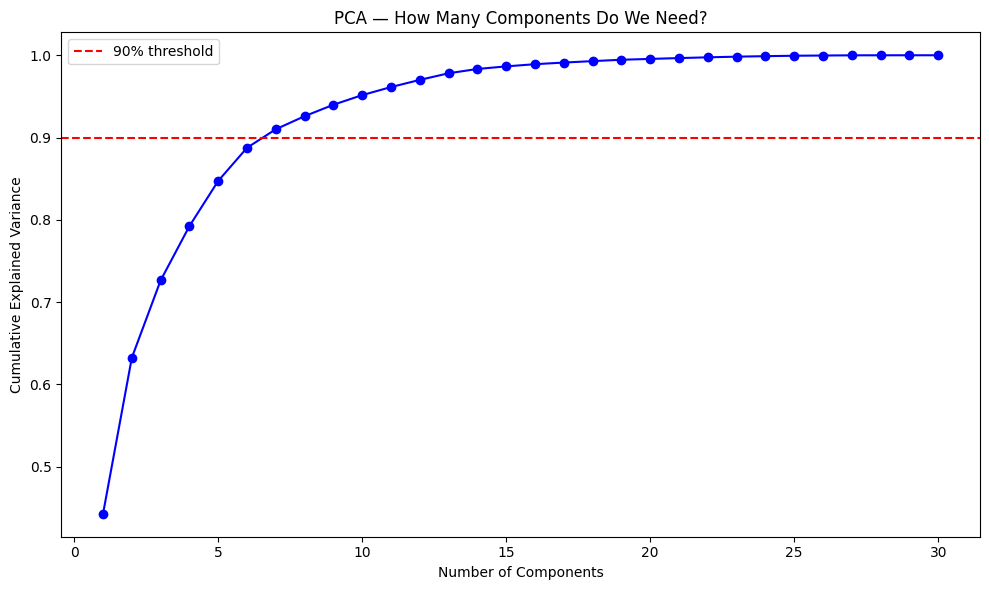

Components needed for 90% variance: 7
Reduction: 30 → 7 features

📊 Without PCA:
   Accuracy: 0.9825
   F1 Score: 0.9861
   ROC-AUC:  0.9812

📊 With PCA:
   Accuracy: 0.9474
   F1 Score: 0.9577
   ROC-AUC:  0.9484


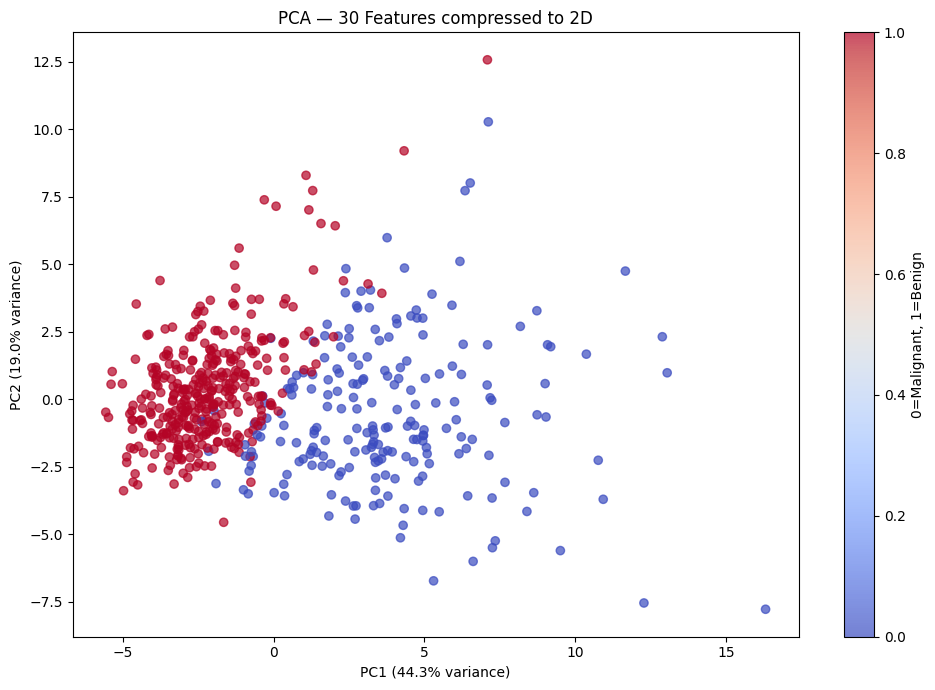


Churn dataset — Components for 90% variance: 3 out of 4


In [ ]:
# ============================================================
# DAY 9 — Dimensionality Reduction & PCA
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

# ── Block 1: Imports ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.datasets import load_breast_cancer
print("Imports done ✅")

# ── Block 2: Load Data ────────────────────────────────────
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)
print("Shape:", X.shape)
print("Features:", X.columns.tolist())

# ── Block 3: Explained Variance Plot ─────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance, marker='o', color='blue')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — How Many Components Do We Need?')
plt.legend()
plt.tight_layout()
plt.show()
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Reduction: {X.shape[1]} → {n_components_90} features")

# ── Block 4: PCA Inside Pipeline ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
pipe_with_pca = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
pipe_without_pca = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
for name, pipe in [("Without PCA", pipe_without_pca),
                    ("With PCA", pipe_with_pca)]:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"\n📊 {name}:")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"   ROC-AUC:  {roc_auc_score(y_test, y_pred):.4f}")

# ── Block 5: 2D Visualisation ─────────────────────────────
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='0=Malignant, 1=Benign')
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA — 30 Features compressed to 2D')
plt.tight_layout()
plt.show()

# ── Block 6: PCA on Churn Dataset ────────────────────────
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
X_churn = df.select_dtypes(include=['int64','float64']).drop(
    'Churn', axis=1, errors='ignore')
y_churn = df['Churn']
X_churn_scaled = StandardScaler().fit_transform(X_churn)
pca_churn = PCA()
pca_churn.fit(X_churn_scaled)
cumvar = np.cumsum(pca_churn.explained_variance_ratio_)
n_comp = np.argmax(cumvar >= 0.90) + 1
print(f"\nChurn dataset — Components for 90% variance: {n_comp} out of {X_churn.shape[1]}")

In [ ]:
# ============================================================
# DAY 11 — Advanced Feature Engineering & Model Interpretation
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("Imports done ✅")

Imports done ✅


In [ ]:
# Load and clean churn dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print("Shape:", df.shape)
print("Churn rate:", df['Churn'].mean().round(3))

Shape: (7032, 20)
Churn rate: 0.266


In [ ]:
# ── 3 Advanced Features for Task 2 ──────────────────────

# 1. Tenure groups (temporal feature)
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-1yr', '1-2yr', '2-4yr', '4+yr'])

# 2. Monthly to Total charges ratio
# High ratio = customer hasn't been here long relative to charges
df['charges_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

# 3. Service count — how many services does customer use?
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df['service_count'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1)

print("New features added ✅")
print("\nTenure groups distribution:")
print(df['tenure_group'].value_counts())
print("\nService count distribution:")
print(df['service_count'].value_counts().sort_index())

New features added ✅

Tenure groups distribution:
tenure_group
4+yr     2239
0-1yr    2175
2-4yr    1594
1-2yr    1024
Name: count, dtype: int64

Service count distribution:
service_count
0      80
1    2247
2     996
3    1041
4    1060
5     825
6     524
7     259
Name: count, dtype: int64


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Update column lists after new features
numeric_cols = X.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(
    include=['object', 'category']).columns.tolist()

print("Numeric cols:", numeric_cols)
print("\nCategorical cols:", categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build preprocessor
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)])

print("\nPreprocessor ready ✅")

Numeric cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charges_ratio', 'service_count']

Categorical cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Preprocessor ready ✅


In [ ]:
# Random Forest Pipeline
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, random_state=42))])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

# XGBoost Pipeline
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0))])
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

# Results
for name, y_pred in [("Random Forest", y_pred_rf),
                      ("XGBoost", y_pred_xgb)]:
    print(f"\n📊 {name}:")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"   ROC-AUC:  {roc_auc_score(y_test, y_pred):.4f}")


📊 Random Forest:
   Accuracy: 0.7846
   F1 Score: 0.5484
   ROC-AUC:  0.6913

📊 XGBoost:
   Accuracy: 0.7790
   F1 Score: 0.5687
   ROC-AUC:  0.7053


/tmp/ipykernel_2741/1423402547.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature',


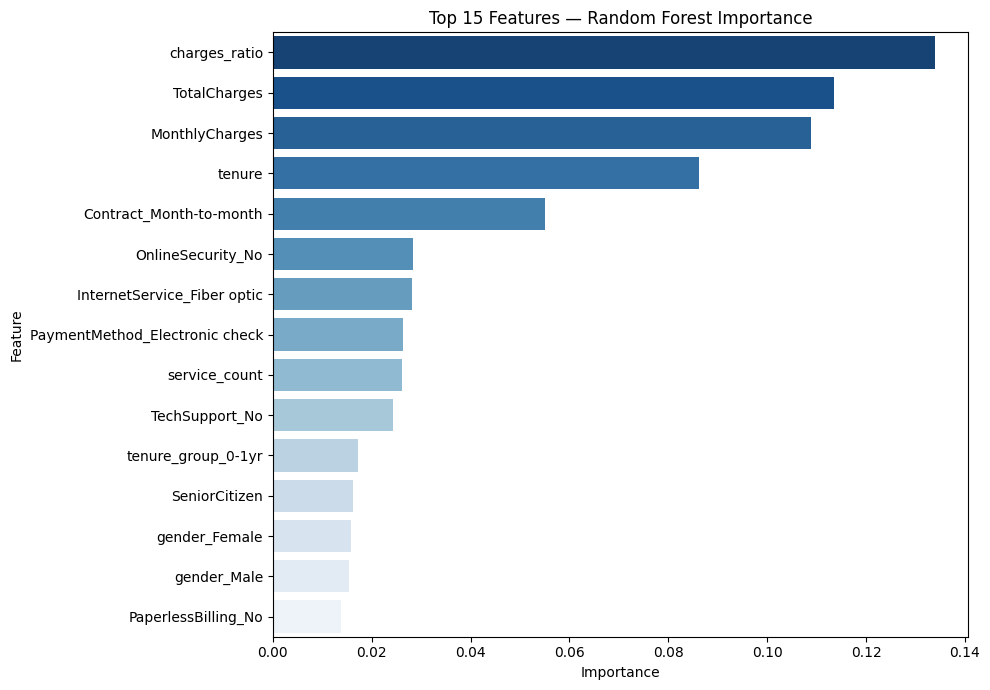


Top 5 most important features:
                Feature  Importance
          charges_ratio    0.133934
           TotalCharges    0.113561
         MonthlyCharges    0.108772
                 tenure    0.086302
Contract_Month-to-month    0.054977


In [ ]:
# Extract feature names after preprocessing
rf_model = rf_pipe.named_steps['classifier']
preprocessor_fitted = rf_pipe.named_steps['preprocessor']

# Get feature names
num_features = numeric_cols
cat_features = preprocessor_fitted\
    .named_transformers_['cat']['encoder']\
    .get_feature_names_out(categorical_cols).tolist()
all_features = num_features + cat_features

# Feature importance plot
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            palette='Blues_r')
plt.title('Top 15 Features — Random Forest Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head(5)[['Feature', 'Importance']].to_string(index=False))

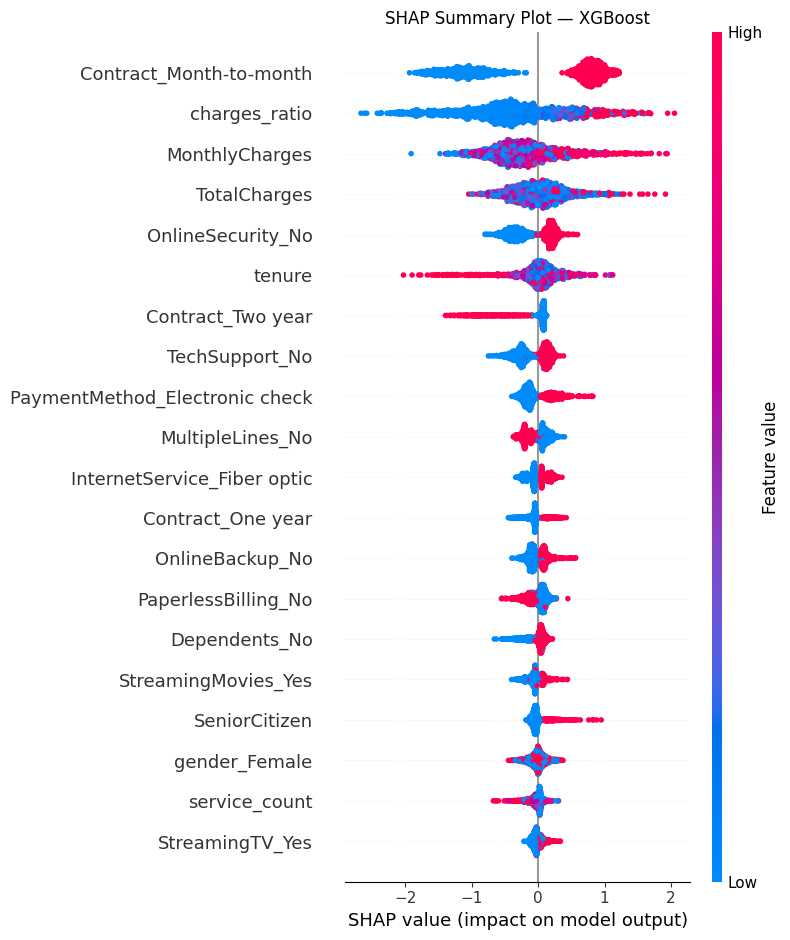

In [ ]:
# Extract preprocessed data for SHAP
X_train_processed = xgb_pipe.named_steps['preprocessor']\
    .transform(X_train)
X_test_processed = xgb_pipe.named_steps['preprocessor']\
    .transform(X_test)

xgb_model = xgb_pipe.named_steps['classifier']

# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_processed)

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed,
                   feature_names=all_features,
                   show=False)
plt.title('SHAP Summary Plot — XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
# Explain a single customer prediction
shap.initjs()

# Pick customer index 0
customer_idx = 0
print("Actual churn:", y_test.iloc[customer_idx])
print("Predicted churn:", xgb_pipe.predict(
    X_test.iloc[[customer_idx]])[0])

# Force plot for this customer
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[customer_idx],
    X_test_processed[customer_idx],
    feature_names=all_features
)
shap.save_html('shap_force_plot.html', force_plot)
print("Force plot saved as shap_force_plot.html ✅")
print("Open the file to see which features drove this prediction!")

Actual churn: 0
Predicted churn: 0
Force plot saved as shap_force_plot.html ✅
Open the file to see which features drove this prediction!


/tmp/ipykernel_2741/641863933.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shap_importance, x='SHAP Importance',


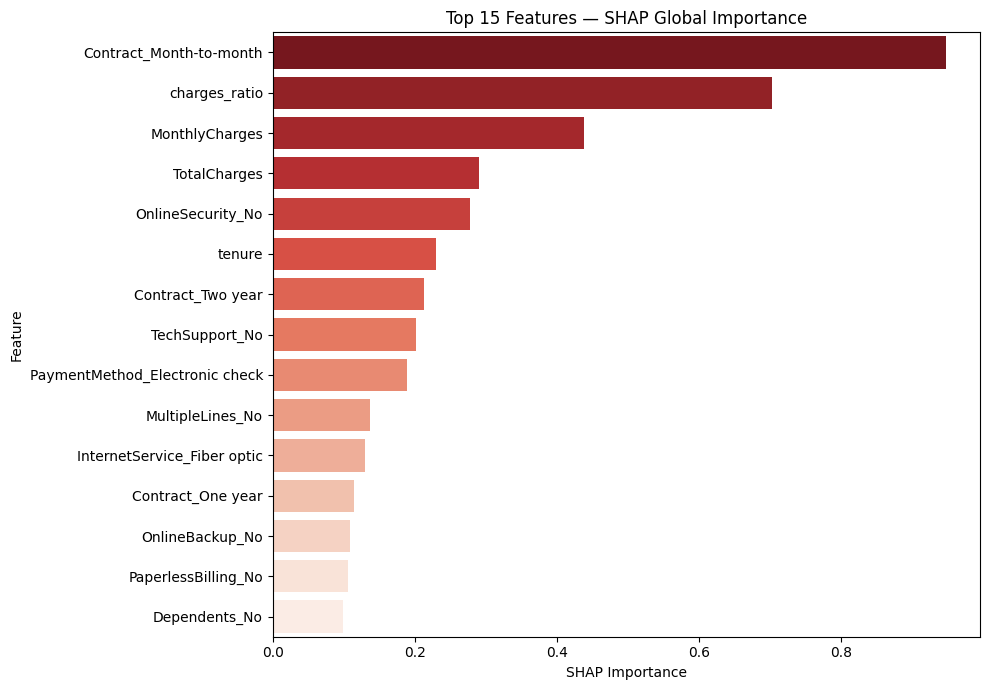


Top 5 features by SHAP importance:
                Feature  SHAP Importance
Contract_Month-to-month         0.948061
          charges_ratio         0.703215
         MonthlyCharges         0.438376
           TotalCharges         0.290650
      OnlineSecurity_No         0.278263


In [ ]:
# Global feature importance via SHAP
shap_importance = pd.DataFrame({
    'Feature': all_features,
    'SHAP Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=shap_importance, x='SHAP Importance',
            y='Feature', palette='Reds_r')
plt.title('Top 15 Features — SHAP Global Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features by SHAP importance:")
print(shap_importance.head(5).to_string(index=False))

In [ ]:
# ============================================================
# DAY 12 — Evaluation Deep Dive & Model Comparison
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve,
                             classification_report)
print("Imports done ✅")

Imports done ✅


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Fixed: Using a verified, highly stable raw data mirror for the Telco Churn dataset
url = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Clean and transform
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Add engineered features from Day 11
df['charges_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df['service_count'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1)

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dynamic column selection
numeric_cols = X.select_dtypes(
    include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(
    include=['object','category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build preprocessing transformers
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('encoder', OneHotEncoder(
        handle_unknown='ignore'))]), categorical_cols)])

print("Data ready ✅ | Shape:", df.shape)

Data ready ✅ | Shape: (7032, 22)


In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000, random_state=42))]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100, random_state=42))]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            random_state=42, eval_metric='logloss', verbosity=0))])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained ✅")

Logistic Regression trained ✅
Random Forest trained ✅
XGBoost trained ✅


In [ ]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print("📊 Full Model Comparison Table:")
print(results_df.round(4).to_string(index=False))

📊 Full Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8003     0.6422  0.5615    0.5991   0.8419
      Random Forest    0.7846     0.6203  0.4893    0.5471   0.8160
            XGBoost    0.7647     0.5613  0.5267    0.5434   0.8110


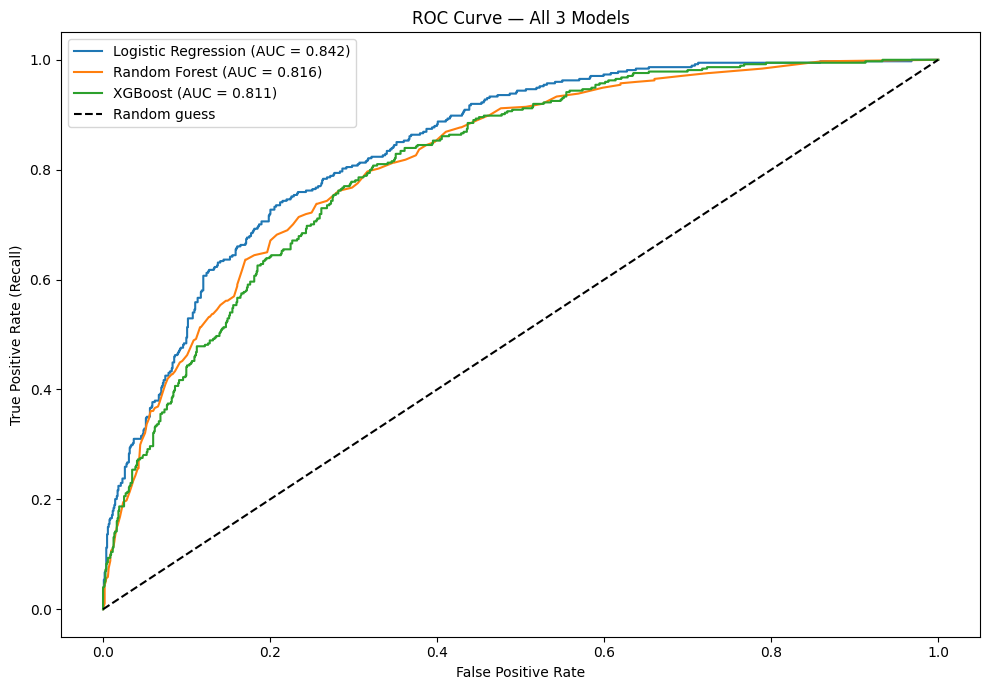

In [ ]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — All 3 Models')
plt.legend()
plt.tight_layout()
plt.show()

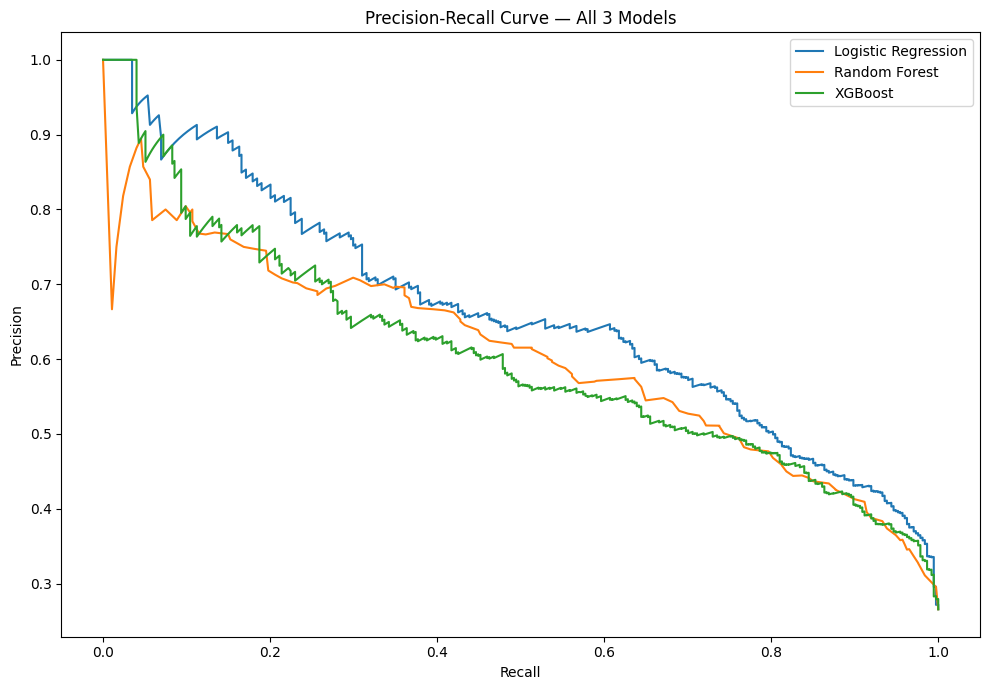

In [ ]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All 3 Models')
plt.legend()
plt.tight_layout()
plt.show()


📊 Logistic Regression:
   Correctly identified churners (TP): 210
   Missed churners (FN): 164 ← expensive mistake!
   False alarms (FP): 117

📊 Random Forest:
   Correctly identified churners (TP): 183
   Missed churners (FN): 191 ← expensive mistake!
   False alarms (FP): 112

📊 XGBoost:
   Correctly identified churners (TP): 197
   Missed churners (FN): 177 ← expensive mistake!
   False alarms (FP): 154


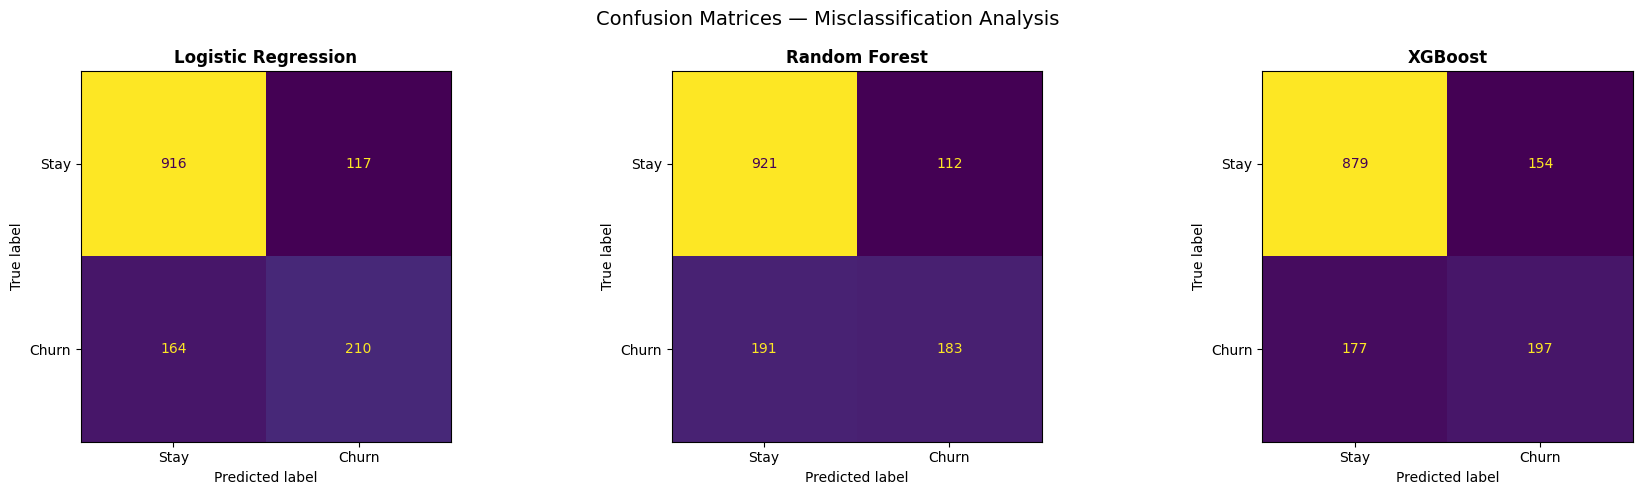

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Stay', 'Churn'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontweight='bold')

    # Print misclassification analysis
    tn, fp, fn, tp = cm.ravel()
    print(f"\n📊 {name}:")
    print(f"   Correctly identified churners (TP): {tp}")
    print(f"   Missed churners (FN): {fn} ← expensive mistake!")
    print(f"   False alarms (FP): {fp}")

plt.suptitle('Confusion Matrices — Misclassification Analysis',
             fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Show why accuracy is misleading here
print("📊 Why Accuracy Alone is Misleading:")
print(f"Dataset churn rate: {y.mean():.1%}")
print("\nA 'dumb' model that predicts everyone stays:")
dummy_accuracy = 1 - y_test.mean()
print(f"Would get accuracy: {dummy_accuracy:.1%}")
print("\nThat's why we care about Recall for the Churn class!")

print("\n📊 Recall for Churn class specifically:")
for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred,
                                    target_names=['Stay', 'Churn'],
                                    output_dict=True)
    churn_recall = report['Churn']['recall']
    churn_f1 = report['Churn']['f1-score']
    print(f"   {name}: Recall={churn_recall:.3f} | F1={churn_f1:.3f}")

📊 Why Accuracy Alone is Misleading:
Dataset churn rate: 26.6%

A 'dumb' model that predicts everyone stays:
Would get accuracy: 73.4%

That's why we care about Recall for the Churn class!

📊 Recall for Churn class specifically:
   Logistic Regression: Recall=0.561 | F1=0.599
   Random Forest: Recall=0.489 | F1=0.547
   XGBoost: Recall=0.527 | F1=0.543


In [ ]:
print("=" * 60)
print("MODEL SELECTION JUSTIFICATION")
print("=" * 60)

best = results_df.loc[results_df['Recall'].idxmax()]
print(f"\nBest model for Churn prediction: {best['Model']}")
print(f"Reason: Highest Recall ({best['Recall']:.3f}) on Churn class")
print("\nBusiness justification:")
print("In churn prediction, missing an actual churner (False Negative)")
print("costs more than a false alarm (False Positive).")
print("A customer incorrectly flagged gets a retention offer — low cost.")
print("A churner we miss = lost revenue forever — high cost.")
print("Therefore Recall is our primary metric, not Accuracy.")

MODEL SELECTION JUSTIFICATION

Best model for Churn prediction: Logistic Regression
Reason: Highest Recall (0.561) on Churn class

Business justification:
In churn prediction, missing an actual churner (False Negative)
costs more than a false alarm (False Positive).
A customer incorrectly flagged gets a retention offer — low cost.
A churner we miss = lost revenue forever — high cost.
Therefore Recall is our primary metric, not Accuracy.


In [1]:
# ============================================================
# DAY 13 — Multi-Model & Cascaded Pipeline Thinking
# ACM SIGAI ML Recruitment | Week 2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, mean_absolute_error, r2_score)
import warnings
warnings.filterwarnings('ignore')
print("Imports done ✅")

Imports done ✅


In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Engineer features from Day 11
df['charges_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df['service_count'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1)

print("Shape:", df.shape)
print("Churn rate:", df['Churn'].mean().round(3))

Shape: (7032, 22)
Churn rate: 0.266


In [3]:
# ── STAGE 1: Will the customer churn? ─────────────────────
X = df.drop('Churn', axis=1)
y_churn = df['Churn']

numeric_cols = X.select_dtypes(
    include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(
    include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('encoder', OneHotEncoder(
        handle_unknown='ignore'))]), categorical_cols)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

# Train Stage 1 model
stage1_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0))])
stage1_model.fit(X_train, y_train)

# Stage 1 predictions
y_pred_stage1 = stage1_model.predict(X_test)
y_prob_stage1 = stage1_model.predict_proba(X_test)[:, 1]

print("📊 Stage 1 — Churn Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stage1):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_stage1):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_stage1):.4f}")
print(f"\nPredicted churners: {y_pred_stage1.sum()} out of {len(y_pred_stage1)}")

📊 Stage 1 — Churn Classifier:
Accuracy: 0.7647
F1 Score: 0.5434
ROC-AUC:  0.8110

Predicted churners: 351 out of 1407


In [4]:
# ── STAGE 2: For predicted churners → how much revenue lost? ──
# Create synthetic revenue loss target
# In real world this would come from actual data
# Here we simulate: revenue loss ≈ MonthlyCharges × remaining tenure
df['revenue_loss'] = df['MonthlyCharges'] * (72 - df['tenure'])
df['revenue_loss'] = df['revenue_loss'].clip(lower=0)

# Get the test set customers Stage 1 flagged as churners
X_test_reset = X_test.reset_index(drop=True)
churner_mask = y_pred_stage1 == 1
X_churners = X_test_reset[churner_mask]

# Revenue loss for those customers
y_revenue = df.loc[X_test.index, 'revenue_loss'].values[churner_mask]

print(f"Customers flagged as churners: {churner_mask.sum()}")
print(f"Revenue loss target stats:")
print(f"  Mean: ${y_revenue.mean():.2f}")
print(f"  Max:  ${y_revenue.max():.2f}")
print(f"  Min:  ${y_revenue.min():.2f}")

# Build Stage 2 model — only on numeric features for simplicity
numeric_pipeline = Pipeline([('scaler', StandardScaler())])
X_churners_numeric = X_churners[numeric_cols]

# Split churners into train/test for Stage 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_churners_numeric, y_revenue,
    test_size=0.2, random_state=42)

stage2_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(random_state=42, verbosity=0))])
stage2_model.fit(X2_train, y2_train)
y_pred_stage2 = stage2_model.predict(X2_test)

print("\n📊 Stage 2 — Revenue Loss Estimator:")
print(f"MAE: ${mean_absolute_error(y2_test, y_pred_stage2):.2f}")
print(f"R²:  {r2_score(y2_test, y_pred_stage2):.4f}")

Customers flagged as churners: 351
Revenue loss target stats:
  Mean: $4266.51
  Max:  $7273.95
  Min:  $108.55

📊 Stage 2 — Revenue Loss Estimator:
MAE: $106.78
R²:  0.9872


In [5]:
# ── STAGE 3: Which retention offer to give? ───────────────
# Based on revenue loss, assign offer tier
# This is how Stage 2 output becomes Stage 3 input!

def assign_offer(revenue_loss):
    if revenue_loss < 500:
        return 0  # Basic offer (email)
    elif revenue_loss < 2000:
        return 1  # Mid offer (discount)
    else:
        return 2  # Premium offer (personal call)

# Create offer labels from Stage 2 predictions
y_offer_train = pd.Series(y2_train).apply(assign_offer).values
y_offer_test = pd.Series(y2_test).apply(assign_offer).values

print("Offer distribution in training:")
print(pd.Series(y_offer_train).value_counts().sort_index())
print("\n0 = Basic email offer")
print("1 = Discount offer")
print("2 = Premium personal call")

# Stage 3 uses Stage 2's predictions as a feature!
X3_train = X2_train.copy()
X3_train['predicted_revenue_loss'] = stage2_model.predict(X2_train)

X3_test = X2_test.copy()
X3_test['predicted_revenue_loss'] = y_pred_stage2

stage3_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        random_state=42, eval_metric='mlogloss', verbosity=0))])
stage3_model.fit(X3_train, y_offer_train)
y_pred_stage3 = stage3_model.predict(X3_test)

print("\n📊 Stage 3 — Retention Offer Classifier:")
print(f"Accuracy: {accuracy_score(y_offer_test, y_pred_stage3):.4f}")
print(f"F1 Score: {f1_score(y_offer_test, y_pred_stage3, average='macro'):.4f}")

Offer distribution in training:
0      2
1     29
2    249
Name: count, dtype: int64

0 = Basic email offer
1 = Discount offer
2 = Premium personal call

📊 Stage 3 — Retention Offer Classifier:
Accuracy: 0.9859
F1 Score: 0.9666


In [6]:
# ── Full Cascade Summary ───────────────────────────────────
print("=" * 60)
print("END-TO-END CASCADED PIPELINE SUMMARY")
print("=" * 60)

print(f"""
🔗 PIPELINE ARCHITECTURE:

  ALL CUSTOMERS ({len(X_test)})
        ↓
  [Stage 1: Churn Classifier — XGBoost]
        ↓
  ┌─────────────────┬──────────────────┐
  │ Stay ({(y_pred_stage1==0).sum()})         │ Churn ({(y_pred_stage1==1).sum()})          │
  │ → No action     │       ↓          │
  └─────────────────┘       ↓          │
                    [Stage 2: Revenue Loss — XGBRegressor]
                            ↓
                    [Stage 3: Offer Classifier — XGBoost]
                            ↓
                    ┌───────┬───────┬────────┐
                    │Basic  │Discount│Premium │
                    │Email  │Offer  │ Call   │
                    └───────┴───────┴────────┘

📊 STAGE METRICS:
  Stage 1 — F1: {f1_score(y_test, y_pred_stage1):.3f} | AUC: {roc_auc_score(y_test, y_prob_stage1):.3f}
  Stage 2 — MAE: ${mean_absolute_error(y2_test, y_pred_stage2):.2f} | R²: {r2_score(y2_test, y_pred_stage2):.3f}
  Stage 3 — F1: {f1_score(y_offer_test, y_pred_stage3, average='macro'):.3f}

✅ WHY 3 MODELS INSTEAD OF 1:
  → Stage 1 answers: Will they churn? (Classification)
  → Stage 2 answers: How much revenue at risk? (Regression)
  → Stage 3 answers: What offer fits best? (Multi-class)
  → Each is a different ML problem type — impossible with 1 model!
""")

END-TO-END CASCADED PIPELINE SUMMARY

🔗 PIPELINE ARCHITECTURE:

  ALL CUSTOMERS (1407)
        ↓
  [Stage 1: Churn Classifier — XGBoost]
        ↓
  ┌─────────────────┬──────────────────┐
  │ Stay (1056)         │ Churn (351)          │
  │ → No action     │       ↓          │
  └─────────────────┘       ↓          │
                    [Stage 2: Revenue Loss — XGBRegressor]
                            ↓
                    [Stage 3: Offer Classifier — XGBoost]
                            ↓
                    ┌───────┬───────┬────────┐
                    │Basic  │Discount│Premium │
                    │Email  │Offer  │ Call   │
                    └───────┴───────┴────────┘

📊 STAGE METRICS:
  Stage 1 — F1: 0.543 | AUC: 0.811
  Stage 2 — MAE: $106.78 | R²: 0.987
  Stage 3 — F1: 0.967

✅ WHY 3 MODELS INSTEAD OF 1:
  → Stage 1 answers: Will they churn? (Classification)
  → Stage 2 answers: How much revenue at risk? (Regression)
  → Stage 3 answers: What offer fits best? (Multi-class)
 

In [7]:
# ── Design YOUR Final Project Cascade ─────────────────────
print("=" * 60)
print("FINAL PROJECT CASCADE DESIGN TEMPLATE")
print("=" * 60)

print("""
Fill this in for your final project:

Problem Domain: ________________________________

Dataset: ________________________________

Stage 1:
  Input features: ________________________________
  Predicts: ________________________________
  Model type: Classification / Regression
  Output passed to Stage 2: ________________________________

Stage 2:
  Input features: original features + Stage 1 output
  Predicts: ________________________________
  Model type: Classification / Regression
  Output passed to Stage 3 (if applicable): ________________

Why multiple models are needed:
  ________________________________
  ________________________________

Example domains to consider:
  • Student performance prediction
  • E-commerce recommendation
  • Medical diagnosis
  • Credit risk assessment
  • Traffic prediction
""")

FINAL PROJECT CASCADE DESIGN TEMPLATE

Fill this in for your final project:

Problem Domain: ________________________________

Dataset: ________________________________

Stage 1:
  Input features: ________________________________
  Predicts: ________________________________
  Model type: Classification / Regression
  Output passed to Stage 2: ________________________________

Stage 2:
  Input features: original features + Stage 1 output
  Predicts: ________________________________
  Model type: Classification / Regression
  Output passed to Stage 3 (if applicable): ________________

Why multiple models are needed:
  ________________________________
  ________________________________

Example domains to consider:
  • Student performance prediction
  • E-commerce recommendation
  • Medical diagnosis
  • Credit risk assessment
  • Traffic prediction

